# Time series modelling
## ARCH/GARCH modelling and volatility analysis

In this notebook, we,

- learn about volatility and volatility modelling
- learn how to analyse volatility using ARCH and GARCH models in Python
- obtain and analyse S&P500 dataset from St. Louis FRED

This notebook draws on,

- [GARCH Models in Python](https://app.datacamp.com/learn/courses/garch-models-in-python) (DataCamp)
- [Master Volatility with ARCH & GARCH Models](https://youtu.be/iImtlBRcczA?si=7AtMWY6rr-3jmSq_) (Roman Paolucci, YouTube)
- [ARCH and GARCH models in Quant Finance](https://github.com/romanmichaelpaolucci/Quant-Guild-Library/blob/main/2025%20Video%20Lectures/47.%20Master%20Volatility%20with%20ARCH%20%26%20GARCH%20Models/arch_garch.ipynb) (Roman Paolucci, GitHub)
- Neusser, K. (2016) 'Models of Volatility' in *Time Series Econometrics*, Springer.

## Objectives

### Model estimation

- estimated parameters help us understand volatility dynamics, viz. persistence ($\alpha+\beta$), long-run variance ($\omega/(1-\alpha-\beta)$), stationarity
- conditional variance $\hat{\sigma}_t^2$ captures volatility clustering
- standardised residuals $z_t$ are a diagnostic output. By assumption, $z_t \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0,1)$

### Forecasting

- variance is used in variance at risk / risk managment, option pricing, portfolio rebalancing
- $\hat{\mu}$ is constant in a constant-mean model
- GARCH variance forecasts mean-revert to the long-run variance $\frac{\omega}{(1-\alpha-\beta)}$ as $h \to \infty$

## Fundamentals of volatility

Returns as a percentage:
$$\text{(return)}=\frac{P_1-P_0}{P_0}$$

Sample mean return:
$$\text{(mean)}=\frac{\sum_{i=1}^n \text{(return)}_i}{n}$$

Sample standard deviation:
$$\text{(volatility)}=\sqrt{\frac{\sum_{i=1}^n (\text{(return)}_i-\text{(mean)})^2}{n-1}}=\sqrt{\text{(variance)}}$$

Monthly volatility:
$$\sigma_{\text{(monthly)}}=\sqrt{21}\sigma_{\text{(daily)}}$$

Annual volatility:
$$\sigma_{\text{(annual)}}=\sqrt{252}\sigma_{\text{(daily)}}$$

## Fundamentals of ARCH/GARCH modelling

Expected return:
$$\mu_t = \mathbb{E}[r_t \mid I_{t-1}]$$

Mean equation:
$$\begin{align*}
r_t&=\mu_t+\epsilon_t \\
&=\ln{(P_t)}-\ln{(P_{t-1})}
\end{align*}$$

Expected volatility:
$$\sigma_t^2=\mathbb{E}[(r_t-\mu_t)^2 \mid I_{t-1}]$$

Residuals:
$$\begin{align*}
\epsilon_t &= \sigma_t z_t, \quad z_t \overset{\text{i.i.d.}}{\sim} (0,1) \\
&= r_t - \mu_t
\end{align*}$$

Standardised residuals:
$$z_t=\frac{\epsilon_t}{\sigma_t}$$

ARCH(p) with the stationarity condition:
$$\sigma_t^2=\omega+\sum_{i=1}^p \alpha_i\epsilon_{t-i}^2, \qquad \sum_{i=1}^p \alpha_i < 1$$

GARCH(p,q) with the stationarity condition:
$$\sigma_t^2=\omega+\sum_{i=1}^p \alpha_i\epsilon_{t-i}^2 + \sum_{j=1}^q\beta_j\sigma_{t-j}^2, \qquad \sum_{i=1}^p \alpha_i + \sum_{i=1}^q \beta_j < 1$$

### GJR-GARCH/EGARCH

[GJR-GARCH](https://vlab.stern.nyu.edu/docs/volatility/GJR-GARCH) and [EGARCH](https://vlab.stern.nyu.edu/docs/volatility/EGARCH) model asymmetric shocks. 

In [194]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import requests as rq

from datetime import datetime
from scipy.stats import iqr, quantile, norm, shapiro, jarque_bera, chi2
from statsmodels.graphics.gofplots import qqplot
from arch import arch_model

## Helpers

In [245]:
# Convert daily volatility to annual
def annual_vol(col):
    return np.sqrt(252) * np.std(col, ddof = 1)

# MSE/MAE
def evaluate(observation, forecast): 
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    mae = mean_absolute_error(observation, forecast)
    print("Mean Absolute Error (MAE): {:.3g}".format(mae))
    mse = mean_squared_error(observation, forecast)
    print("Mean Squared Error (MSE): {:.3g}".format(mse))
    return mae, mse

# Binwidth
def freedman_diaconis(vec):
    vec = np.asarray(vec)
    return 2 * iqr(vec) * len(vec) ** (-1 / 3)

def fd_bins(vec):
    vec = np.asarray(vec)
    return int((np.max(vec) - np.min(vec)) / freedman_diaconis(vec))

# Investigate a date col
def investigate_dates(date_col, freq = "D"):
    dates = pd.to_datetime(date_col)

    first_date = dates.min()
    last_date = dates.max()

    full_range = pd.date_range(first_date, last_date, freq = freq)

    missing = full_range.difference(dates)
    duplicates = dates[dates.duplicated()]
    
    gaps = dates.sort_values().diff().value_counts()

    return {
        "start": first_date,
        "end": last_date,
        "expected_count": len(full_range),
        "actual_count": len(dates),
        "missing_count": len(missing),
        "missing_dates": missing.tolist(),
        "duplicate_count": duplicates.shape[0],
        "duplicate_dates": duplicates.tolist(),
        "gap_distribution": gaps
    }

# Convert daily volatility to monthly
def monthly_vol(col):
    return np.sqrt(21) * np.std(col, ddof = 1)

# Read in a text file
def read_txt(path):
    with open(path,"r") as f:
        string = f.read()
    return string

# Read a FRED API into a df
def request_fred_df(base_url, endpoint, parameters):
    res = rq.get(base_url + endpoint, params = parameters)
    
    if res.status_code == 200:
        res_data = res.json()
        return pd.DataFrame(res_data["observations"])
    else:
        print("Failed to retrieve data. Status code:", res.status_code)
        return None

## S&P500 data

In [196]:
# API key
path = "C:/data/fred_api_key.txt"
api_key = read_txt(path)

# Base URL
base_url = "https://api.stlouisfed.org/fred/"

# Assign endpoint
endpoint = "series/observations"

# Assign parameters
# https://fred.stlouisfed.org/series/SP500
series_id = "SP500"
start_date = "2000-01-01"
end_date = "2026-03-19"
#ts_frequency
#ts_units

parameters = {
    'series_id': series_id,
    'api_key': api_key,
    'file_type': 'json',
    'observation_start': start_date,
    'observation_end': end_date,
    # 'frequency': ts_frequency
    # 'units': ts_units
}

In [197]:
# Make request to FRED API
snp = request_fred_df(base_url, endpoint, parameters)

In [198]:
# Format the data
snp = snp[["date", "value"]]
snp["date"] = pd.to_datetime(snp["date"])
snp["value"] = pd.to_numeric(snp["value"], errors = "coerce")

snp.head()

,date,value
0,2016-03-25,NaN
1,2016-03-28,2037.05
2,2016-03-29,2055.01
3,2016-03-30,2063.95
4,2016-03-31,2059.74


In [199]:
# Investigate NaNs
pd.DataFrame({
    "col": snp.columns,
    "value": [snp[c].isnull().sum() for c in snp.columns]
})

,col,value
0,date,0
1,value,95


In [200]:
# Investigate duplicates
snp["date"].duplicated().sum()

np.int64(0)

In [201]:
# Investigate discontinuities
dt_log = investigate_dates(snp.date)
dt_log["gap_distribution"]

date
1 days    2083
3 days     521
Name: count, dtype: int64

In [202]:
dt_log["missing_dates"][:10]

[Timestamp('2016-03-26 00:00:00'),
 Timestamp('2016-03-27 00:00:00'),
 Timestamp('2016-04-02 00:00:00'),
 Timestamp('2016-04-03 00:00:00'),
 Timestamp('2016-04-09 00:00:00'),
 Timestamp('2016-04-10 00:00:00'),
 Timestamp('2016-04-16 00:00:00'),
 Timestamp('2016-04-17 00:00:00'),
 Timestamp('2016-04-23 00:00:00'),
 Timestamp('2016-04-24 00:00:00')]

These are weekends.

In [203]:
snp[snp["value"].isnull()].head(10)

,date,value
0,2016-03-25,NaN
46,2016-05-30,NaN
71,2016-07-04,NaN
116,2016-09-05,NaN
174,2016-11-24,NaN
196,2016-12-26,NaN
201,2017-01-02,NaN
211,2017-01-16,NaN
236,2017-02-20,NaN
275,2017-04-14,NaN


And these are bank holidays.

## Returns and volatility

In [204]:
# Compute the returns
snp["pct_return"] = 100 * snp["value"].pct_change(fill_method = None)
snp["log_return"] = np.log(snp["value"]) - np.log(snp["value"].shift(1))

snp.head()

,date,value,pct_return,log_return
0,2016-03-25,NaN,NaN,NaN
1,2016-03-28,2037.05,NaN,NaN
2,2016-03-29,2055.01,0.881667,0.008778
3,2016-03-30,2063.95,0.435034,0.004341
4,2016-03-31,2059.74,-0.203978,-0.002042


In [205]:
# Monthly volatility
df = snp.copy()

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df.groupby(["year", "month"])["log_return"].agg(monthly_vol = lambda c: np.sqrt(21) * np.std(c, ddof = 1)).head()

monthly_vol
year month             
2016 3         0.024925
     4         0.029302
     5         0.032881
     6         0.053890
     7         0.019747

In [206]:
# Annual volatility
df.groupby("year")["log_return"].agg(annual_vol = lambda c: np.sqrt(252) * np.std(c, ddof = 1)).head()

,annual_vol
year,
2016,0.109544
2017,0.066229
2018,0.164500
2019,0.125300
2020,0.351092


## Custom function

Construct a custom function and simulate the ARCH/GARCH process.

In [207]:
# Define an ARCH(1)/GARCH(1,1) function
def simulate_GARCH(n, omega, alpha, beta = 0, mu = 0, burnin = 50):
    N = n + burnin
    z = np.random.normal(loc = 0, scale = 1, size = N)
    sigma2 = np.zeros(N)
    eps = np.zeros(N)
    y = np.zeros(N)
    
    sigma2[0] = omega / (1 - alpha - beta)
    eps[0] = np.sqrt(sigma2[0]) * z[0]
    y[0] = mu + eps[0]
    
    for t in range(1, N):
        sigma2[t] = omega + alpha * eps[t - 1]**2 + beta * sigma2[t - 1]
        eps[t] = np.sqrt(sigma2[t]) * z[t]
        y[t] = mu + eps[t]

    sigma2 = sigma2[burnin:]
    eps = eps[burnin:]
    y = y[burnin:]

    return (eps, sigma2, y)


ARCH(1)/GARCH(1,1) variance:



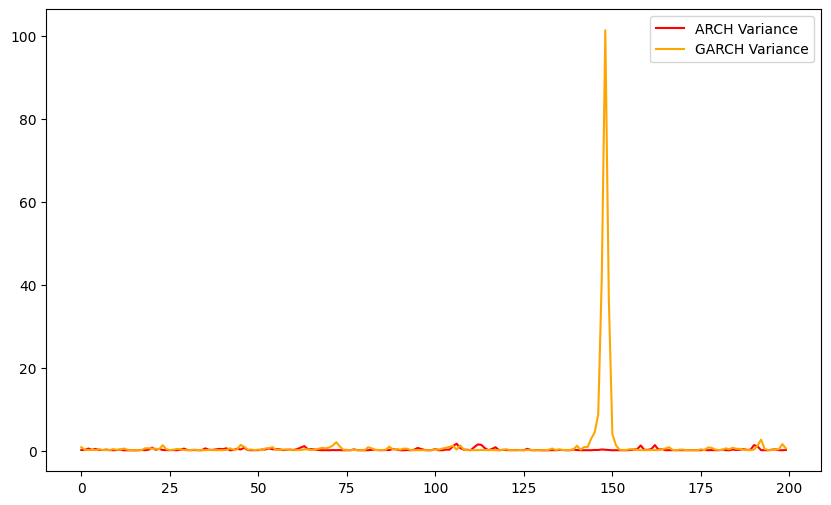

In [208]:
# Simulate a ARCH(1) series
arch_resid, arch_variance, model = simulate_GARCH(
    n = 200, 
    omega = 0.1, 
    alpha = 0.7
)

# Simulate a GARCH(1,1) series
garch_resid, garch_variance, model = simulate_GARCH(
    n = 200, 
    omega = 0.1, 
    alpha = 0.7, 
    beta = 0.1
)

plt.figure(figsize = (10, 6))
# Plot the ARCH variance
plt.plot(arch_variance, color = 'red', label = 'ARCH Variance')

# Plot the GARCH variance
plt.plot(garch_variance, color = 'orange', label = 'GARCH Variance')
plt.legend()

print("\nARCH(1)/GARCH(1,1) variance:\n")
plt.show()


GARCH(1,1) variance and residuals:



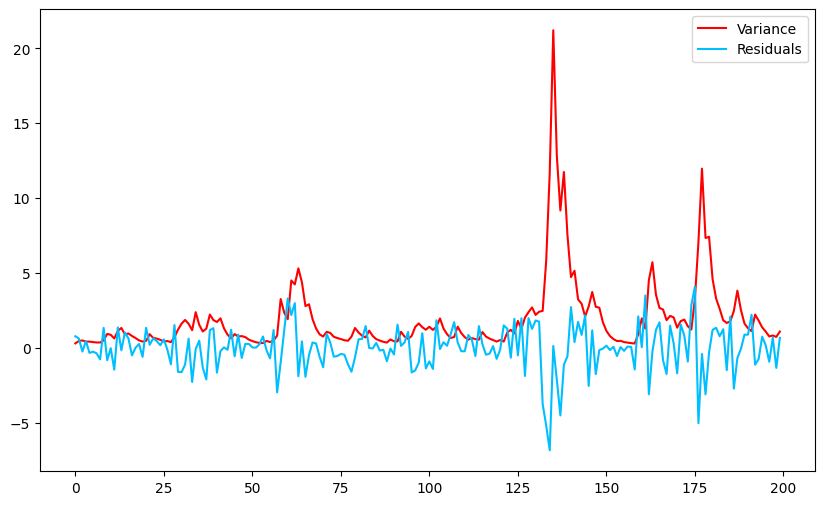

In [209]:
# Second simulated GARCH
sim_resid, sim_variance, model = simulate_GARCH(
    n = 200,  
    omega = 0.1,
    alpha = 0.3, 
    beta = 0.6
)

plt.figure(figsize = (10, 6))
plt.plot(sim_variance, color = 'red', label = 'Variance')
plt.plot(sim_resid, color = 'deepskyblue', label = 'Residuals')
plt.legend(loc='upper right')

print("\nGARCH(1,1) variance and residuals:\n")
plt.show()

## Canned routine

Explore the ARCH/GARCH routine on the S&P500 dataset.

``` Python
# arch_model parameters
mean = ["zero", "constant", "AR"]
vol = ["ARCH", "GARCH", "EGARCH"]
dist = ["normal", "t", "skewt"]
```

In [210]:
# Filter out NaNs and scale the log returns
snp_returns = snp["log_return"].dropna() * 100

### Normal model

#### Fit the model and extract results

In [211]:
# Specify GARCH model assumptions
basic_gm = arch_model(snp_returns, p = 1, q = 1, mean = "constant", vol = "GARCH", dist = "normal")

# Fit the model
gm_result = basic_gm.fit(update_freq = 4)

# Display model fitting summary
print(gm_result.summary())

Iteration:      4,   Func. Count:     33,   Neg. LLF: 3282.4469130325197
Iteration:      8,   Func. Count:     56,   Neg. LLF: 3083.126575009796
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3083.1211664513626
            Iterations: 11
            Function evaluations: 70
            Gradient evaluations: 11
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3083.12
Distribution:                  Normal   AIC:                           6174.24
Method:            Maximum Likelihood   BIC:                           6197.40
                                        No. Observations:                 2415
Date:                Wed, Mar 25 2026   Df Residuals:                     2414
Time:        


Standardised residuals and standard deviation (normal model):



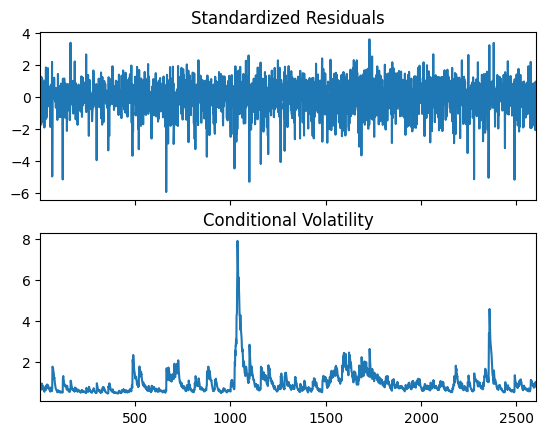

In [212]:
# Plot fitted results
gm_result.plot()

print("\nStandardised residuals and standard deviation (normal model):\n")
plt.show()

#### Extract the series

In [213]:
# Extract residuals
gm_residuals = gm_result.resid
#std_resid = gm_result.resid / gm_result.conditional_volatility
gm_std_resid = gm_result.std_resid

# Extract standard deviation series
gm_std_dev = gm_result.conditional_volatility

# Extract conditional variance series: sigma_t^2
gm_variance = gm_std_dev ** 2

# Fitted parameters
gm_params = gm_result.params

print("\nParameter estimates:\n")
print(gm_params)


Parameter estimates:

mu          0.088119
omega       0.037530
alpha[1]    0.182091
beta[1]     0.790589
Name: params, dtype: float64


In [214]:
# Check the ARCH (shock) and GARCH (persistence) terms for stationarity
print("\nIs the stationarity condition satisfied?\n")
gm_params["alpha[1]"] + gm_params["beta[1]"] < 1


Is the stationarity condition satisfied?



np.True_

#### Inspect residuals


Distribution of standardised residuals:



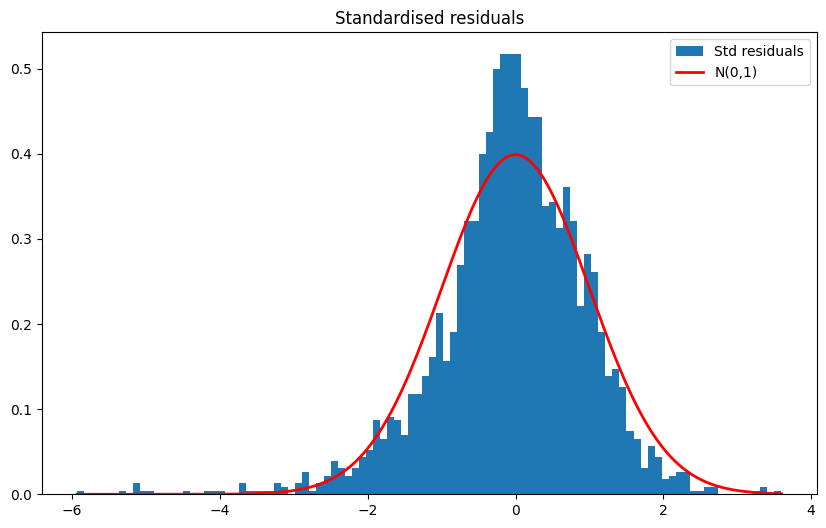

In [215]:
# Distribution of standardised residuals
plt.figure(figsize = (10, 6))
plt.hist(gm_std_resid, bins = 100, density = True, label = "Std residuals")

x = np.linspace(gm_std_resid.min(), gm_std_resid.max(), 200)
plt.plot(x, norm.pdf(x, loc = 0, scale = 1), color = "red", linewidth = 2, label = "N(0,1)")

plt.title("Standardised residuals")
plt.legend()

print("\nDistribution of standardised residuals:\n")
plt.show()

In [216]:
# Test normality formally
# H0: X ~ N in both tests
norm_test = pd.DataFrame({
    "test": ["Shapiro-Wilk", "Jarque-Bera"],
    "stat": [shapiro(gm_std_resid).statistic, jarque_bera(gm_std_resid).statistic],
    "pval": [shapiro(gm_std_resid).pvalue, jarque_bera(gm_std_resid).pvalue]
})
norm_test["p<0.05"] = norm_test["pval"] < 0.05

print("\nTest standardised residuals for normality:\n")
norm_test 


Test standardised residuals for normality:



,test,stat,pval,p<0.05
0,Shapiro-Wilk,0.965467,1.302009e-23,True
1,Jarque-Bera,991.780173,4.341821e-216,True


Formal tests seem to confirm what the graph suggests. Both reject normality. The graph shows us a slight left skew and a number of outliers.

#### Forecast

In [217]:
# Make 5-period ahead forecast
gm_forecast = gm_result.forecast(horizon = 5)

# Print the forecast variance
print("\nVariance forecast:\n")
print(gm_forecast.variance[-1:])


Variance forecast:

           h.1       h.2       h.3       h.4       h.5
2604  0.877497  0.891054  0.904241  0.917067  0.929543


In [218]:
# Extract the forecasted conditional mean
gmfc_mean = gm_forecast.mean

# Extract the forecasted conditional variance (primary output)
gmfc_variance = gm_forecast.variance

## Skewed distribution model

### Fit the model and extract results

In [219]:
# Specify GARCH model assumptions
skewt_gm = arch_model(snp_returns, p = 1, q = 1, mean = "constant", vol = "GARCH", dist = "skewt")

# Fit the model
sk_result = skewt_gm.fit(update_freq = 4)

# Display model fitting summary
print(sk_result.summary())

Iteration:      4,   Func. Count:     40,   Neg. LLF: 3006.334105588149
Iteration:      8,   Func. Count:     72,   Neg. LLF: 337157.406009416
Iteration:     12,   Func. Count:    104,   Neg. LLF: 2974.823703417477
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2974.823702579876
            Iterations: 13
            Function evaluations: 111
            Gradient evaluations: 13
                           Constant Mean - GARCH Model Results                           
Dep. Variable:                        log_return   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                 GARCH   Log-Likelihood:               -2974.82
Distribution:      Standardized Skew Student's t   AIC:                           5961.65
Method:                       Maximum Likelihood   BIC:                           5996.38
                                   


Standardised residuals and standard deviation (skewed t model):



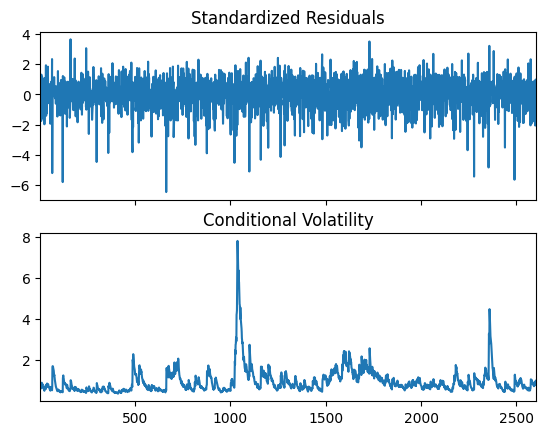

In [220]:
# Plot fitted results
sk_result.plot()

print("\nStandardised residuals and standard deviation (skewed t model):\n")
plt.show()

### Compare volatility


Compare normal and skewed t volatility:



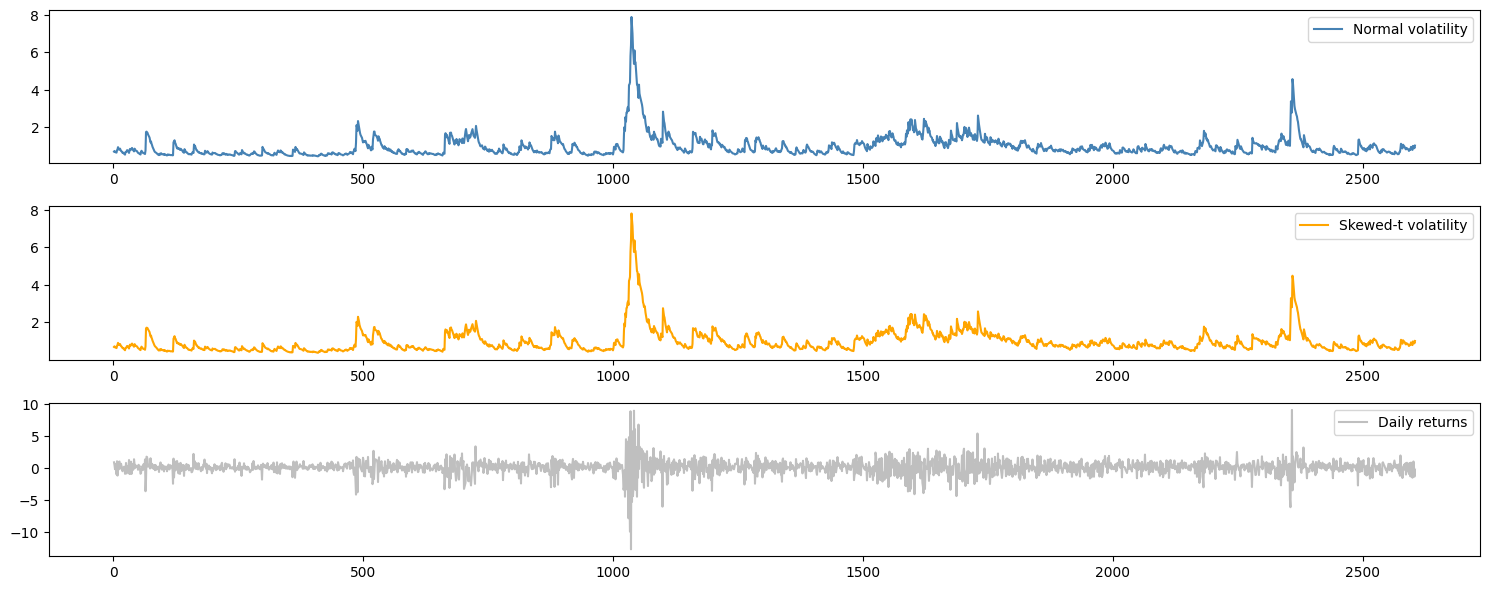

In [221]:
# Get model estimated volatility
sk_std_dev = sk_result.conditional_volatility

# Plot model fitting results
#plt.figure(figsize = (10, 6))
#plt.plot(sk_std_dev, color = "gold", label = "Skewed-t volatility")
#plt.plot(gm_std_dev, color = "red", label = "Normal volatility")
#plt.plot(snp_returns, color = "grey", label = "Daily returns", alpha = 0.2)
#plt.legend(loc = "upper right")

fig, axes = plt.subplots(3, 1, figsize = (15, 6))

axes[0].plot(gm_std_dev, color = "steelblue", label = "Normal volatility")
axes[0].legend(loc = "upper right")
axes[1].plot(sk_std_dev, color = "orange", label = "Skewed-t volatility")
axes[1].legend(loc = "upper right")
axes[2].plot(snp_returns, color = "grey", label = "Daily returns", alpha = 0.5)
axes[2].legend(loc = "upper right")

print("\nCompare normal and skewed t volatility:\n")
plt.tight_layout()
plt.show()

### Inspect residuals


Compare normal and skewed t standardised residuals:



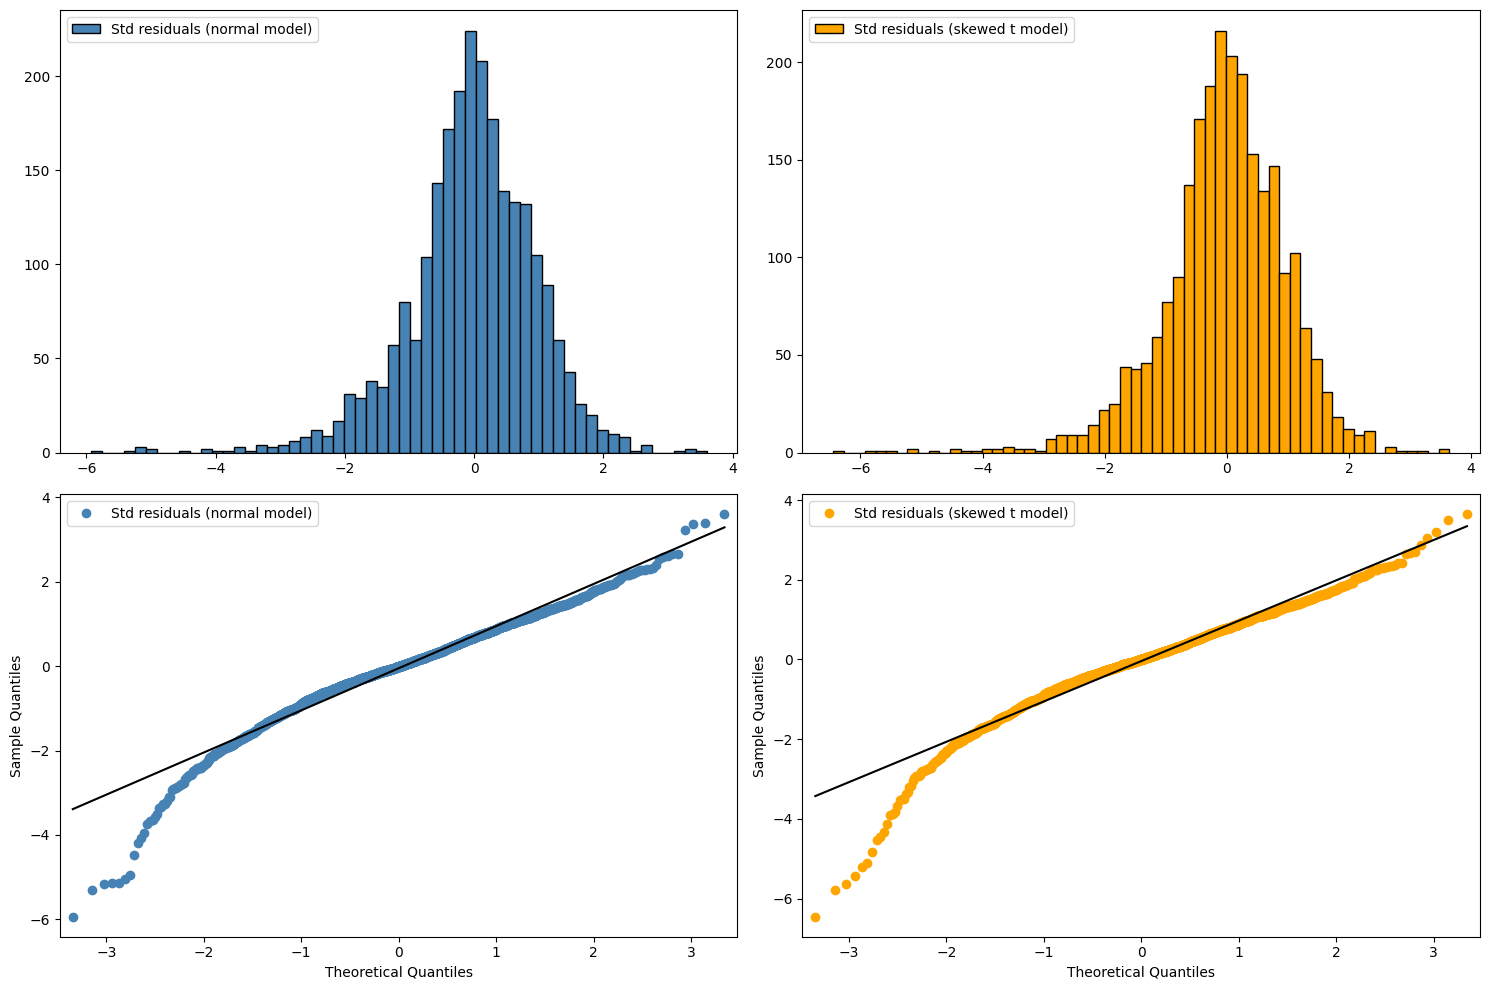

In [222]:
# Extract the standardised residuals
sk_std_resid = sk_result.std_resid

fig, axes = plt.subplots(2, 2, figsize = (15, 10))

axes[0, 0].hist(gm_std_resid, bins = fd_bins(gm_std_resid), color = "steelblue", edgecolor = "black", label = "Std residuals (normal model)")
axes[0, 0].legend(loc = "upper left")
axes[0, 1].hist(sk_std_resid, bins = fd_bins(sk_std_resid), color = "orange", edgecolor = "black", label = "Std residuals (skewed t model)")
axes[0, 1].legend(loc = "upper left")

qqplot(
    gm_std_resid, line = "s", ax = axes[1, 0], 
    markerfacecolor = "steelblue", 
    markeredgecolor = "steelblue",
    label = "Std residuals (normal model)"
)
axes[1, 0].legend(loc = "upper left")
axes[1, 0].get_lines()[1].set_color("black")
qqplot(
    sk_std_resid, line = "s", ax = axes[1, 1], 
    markerfacecolor = "orange", markeredgecolor = "orange", 
    label = "Std residuals (skewed t model)"
)
axes[1, 1].legend(loc = "upper left")
axes[1, 1].get_lines()[1].set_color("black")

print("\nCompare normal and skewed t standardised residuals:\n")
plt.tight_layout()
plt.show()

There is, perhaps, a perceptible improvement to the smoothness of the QQ curve in the skewed t model.

### Compare the models

In [223]:
# Likelihood ratio test
# H0: normal model sufficient
ell_normal = gm_result.loglikelihood
ell_skewt  = sk_result.loglikelihood

lr_stat = 2 * (ell_skewt - ell_normal)
p_value = chi2.sf(lr_stat, df = 2)

# Log likelihood, AIC, BIC
model_comparison = pd.DataFrame({
    "model": ["normal", "skewed t"],
    "log_lik": [gm_result.loglikelihood, sk_result.loglikelihood],
    "AIC": [gm_result.aic, sk_result.aic],
    "BIC": [gm_result.bic, sk_result.bic]
})

print("\nModel comparison:\n")
print(model_comparison)
print("\nLikelihood ratio test:\n")
print(f"Statistic: {lr_stat:.2f}\np-value: {p_value:.4e}\np<0.05: {p_value < 0.05}")



Model comparison:

      model      log_lik          AIC          BIC
0    normal -3083.121166  6174.242333  6197.400151
1  skewed t -2974.823703  5961.647405  5996.384133

Likelihood ratio test:

Statistic: 216.59
p-value: 9.2685e-48
p<0.05: True


AIC, BIC and the log-likelihood test all indicate that the skewed t model is a better fit.

## Constant and AR mean models

In [224]:
# Specify GARCH model assumptions
norm_ar_gm = arch_model(snp_returns, p = 1, q = 1, mean = "AR", vol = "GARCH", dist = "normal")

# Fit the model
armean_result = norm_ar_gm.fit(update_freq = 4)

# Constant mean model
cmean_result = gm_result

Iteration:      4,   Func. Count:     33,   Neg. LLF: 3282.4469130325197
Iteration:      8,   Func. Count:     56,   Neg. LLF: 3083.126575009796
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3083.1211664513626
            Iterations: 11
            Function evaluations: 70
            Gradient evaluations: 11


In [225]:
print("\nNormal model with a constant mean:\n")
print(cmean_result.summary())


Normal model with a constant mean:

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3083.12
Distribution:                  Normal   AIC:                           6174.24
Method:            Maximum Likelihood   BIC:                           6197.40
                                        No. Observations:                 2415
Date:                Wed, Mar 25 2026   Df Residuals:                     2414
Time:                        08:50:57   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0881  1.49

In [226]:
print("\nNormal model with an AR mean:\n")
print(armean_result.summary())


Normal model with an AR mean:

                           AR - GARCH Model Results                           
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3083.12
Distribution:                  Normal   AIC:                           6174.24
Method:            Maximum Likelihood   BIC:                           6197.40
                                        No. Observations:                 2415
Date:                Wed, Mar 25 2026   Df Residuals:                     2414
Time:                        08:50:58   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
Const          0.0881  1.494e-02


Correlation coefficient:

1.0

Compare constant mean and AR mean volatility:



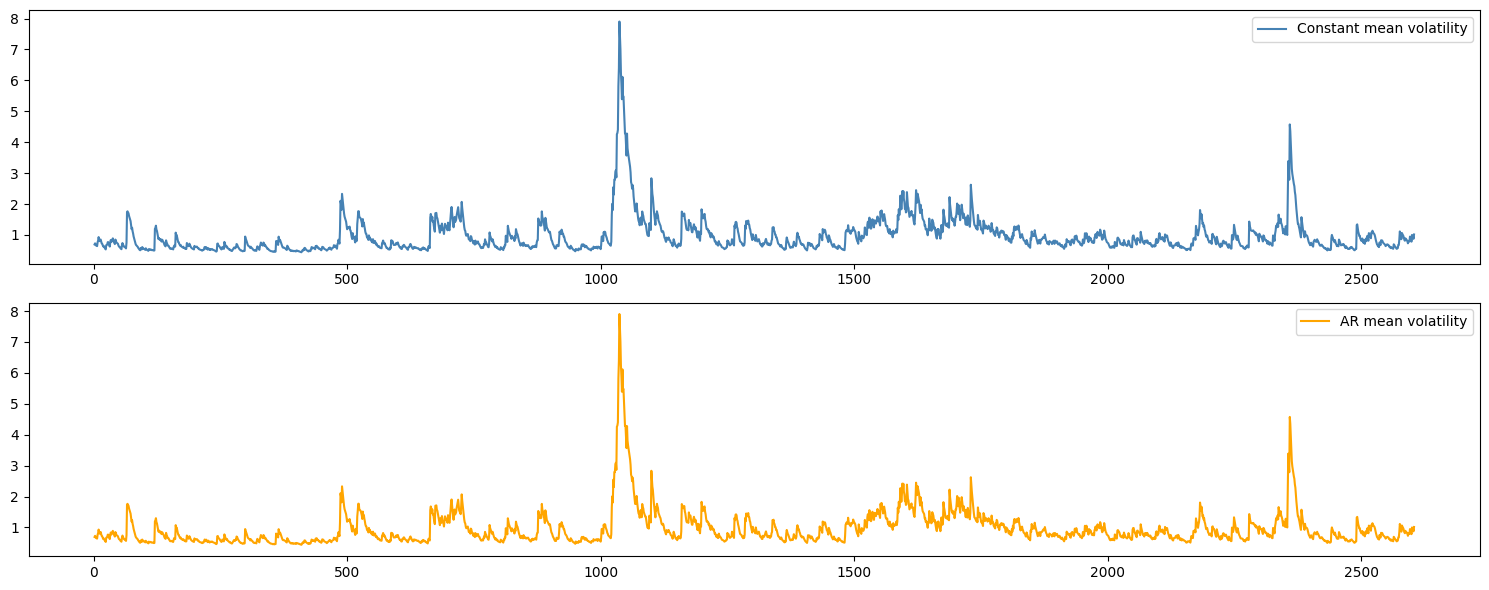

In [227]:
# Plot model volatility
cmean_vol = cmean_result.conditional_volatility
armean_vol = armean_result.conditional_volatility

# Check correlation of volatility estimations
print("\nCorrelation coefficient:\n")
print(np.corrcoef(cmean_vol, armean_vol)[0,1])

#plt.figure(figsize = (10, 6))
#plt.plot(cmean_vol, color = "steelblue", label = "Constant mean volatility")
#plt.plot(armean_vol, color = "orange", label = "AR mean volatility")
#plt.legend(loc = "upper right")
#plt.show()

fig, axes = plt.subplots(2, 1, figsize = (15, 6))

axes[0].plot(cmean_vol, color = "steelblue", label = "Constant mean volatility")
axes[0].legend(loc = "upper right")
axes[1].plot(armean_vol, color = "orange", label = "AR mean volatility")
axes[1].legend(loc = "upper right")

print("\nCompare constant mean and AR mean volatility:\n")
plt.tight_layout()

Modelling volatility with constant and AR mean fetches apparently indistinguishable results with a near perfect correlation. The graphs agree with the summary readouts, which report identical coefficients. Volatility clustering is driven predominantly by the error.

## GJR-GARCH and EGARCH models

In [228]:
# Fit the GJR-GARCH
gjrgm_gm = arch_model(snp_returns, p = 1, q = 1, o = 1, mean = "constant", vol = "GARCH", dist = "skewt")
gjrgm_result = gjrgm_gm.fit(update_freq = 5)
gjrgm_vol = gjrgm_result.conditional_volatility

# Fit the EGARCH
egarch_gm = arch_model(snp_returns, p = 1, q = 1, o = 1, mean = "constant", vol = "EGARCH", dist = "skewt")
egarch_result = egarch_gm.fit(update_freq = 5)
egarch_vol = egarch_result.conditional_volatility

Iteration:      5,   Func. Count:     50,   Neg. LLF: 53250.86681139164
Iteration:     10,   Func. Count:     96,   Neg. LLF: 2943.211807330741
Iteration:     15,   Func. Count:    139,   Neg. LLF: 2938.7794980941635
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2938.7794980941635
            Iterations: 16
            Function evaluations: 146
            Gradient evaluations: 16
Iteration:      5,   Func. Count:     57,   Neg. LLF: 96244.24017792185
Iteration:     10,   Func. Count:    103,   Neg. LLF: 2928.4649885804465
Iteration:     15,   Func. Count:    142,   Neg. LLF: 2928.410837539116
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2928.410837539038
            Iterations: 15
            Function evaluations: 142
            Gradient evaluations: 15



S&P500 returns, GJR-GARCH and EGARCH estimated volatility:



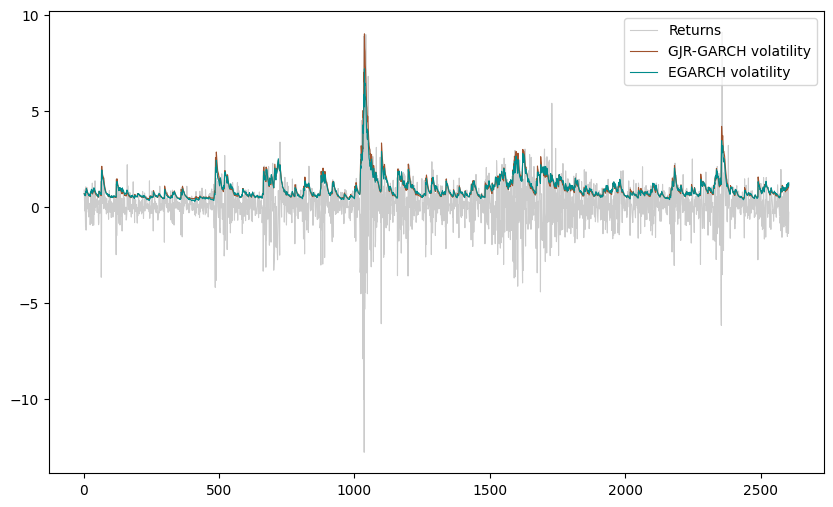

In [229]:
plt.figure(figsize = (10, 6))
# Plot the returns
plt.plot(snp_returns, linewidth = 0.8, color = "grey", alpha = 0.4, label = "Returns")

# Plot GJR-GARCH estimated volatility
plt.plot(gjrgm_vol, linewidth = 0.8, color = "sienna", label = "GJR-GARCH volatility")

# Plot EGARCH  estimated volatility
plt.plot(egarch_vol, linewidth = 0.8, color = "darkcyan", label = "EGARCH volatility")

plt.legend(loc = "upper right")

print("\nS&P500 returns, GJR-GARCH and EGARCH estimated volatility:\n")
plt.show()

## Assess a model

Diagnostics
- normal residuals
- residuals without serial correlation

Significance
- t-statistic
- std error

Model comparison (goodness of fit)
- log-likelihood (a higher log-likelihood indicates a better fit)
- [AIC](https://en.wikipedia.org/wiki/Akaike_information_criterion)/[BIC](https://en.wikipedia.org/wiki/Bayesian_information_criterion) (a lower criterion indicates a better model)
- likelihood ratio

Backtesting
- assess forecast accuracy with MSE/MAE

In [230]:
print("\narch_model results readout:\n")
gm_result


arch_model results readout:



                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3083.12
Distribution:                  Normal   AIC:                           6174.24
Method:            Maximum Likelihood   BIC:                           6197.40
                                        No. Observations:                 2415
Date:                Wed, Mar 25 2026   Df Residuals:                     2414
Time:                        08:50:57   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0881  1.494e-02      5.899  3.652e-09 [5.884e-0

In [231]:
# Docstring
help(gm_result)

Help on ARCHModelResult in module arch.univariate.base object:

class ARCHModelResult(ARCHModelFixedResult)
 |  ARCHModelResult(
 |      params: numpy.ndarray[tuple[int], numpy.dtype[numpy.float64]],
 |      param_cov: numpy.ndarray[tuple[int, ...], numpy.dtype[numpy.float64]] | None,
 |      r2: float,
 |      resid: numpy.ndarray[tuple[int], numpy.dtype[numpy.float64]],
 |      volatility: numpy.ndarray[tuple[int], numpy.dtype[numpy.float64]],
 |      cov_type: str,
 |      dep_var: pandas.Series,
 |      names: list[str],
 |      loglikelihood: float,
 |      is_pandas: bool,
 |      optim_output: scipy.optimize._optimize.OptimizeResult,
 |      fit_start: int,
 |      fit_stop: int,
 |      model: arch.univariate.base.ARCHModel
 |  ) -> None
 |
 |  Results from estimation of an ARCHModel model
 |
 |  Parameters
 |  ----------
 |  params : ndarray
 |      Estimated parameters
 |  param_cov : {ndarray, None}
 |      Estimated variance-covariance matrix of params.  If none, calls meth

In [232]:
# A list of output elements
print("\nElements available in arch_model results:\n")
[x for x in dir(gm_result) if not x.startswith("_")]


Elements available in arch_model results:



['aic',
 'arch_lm_test',
 'bic',
 'conditional_volatility',
 'conf_int',
 'convergence_flag',
 'cov_type',
 'fit_start',
 'fit_stop',
 'forecast',
 'hedgehog_plot',
 'loglikelihood',
 'model',
 'nobs',
 'num_params',
 'optimization_result',
 'param_cov',
 'params',
 'plot',
 'pvalues',
 'resid',
 'rsquared',
 'rsquared_adj',
 'scale',
 'std_err',
 'std_resid',
 'summary',
 'tvalues']

### ACF


Standardised residuals:



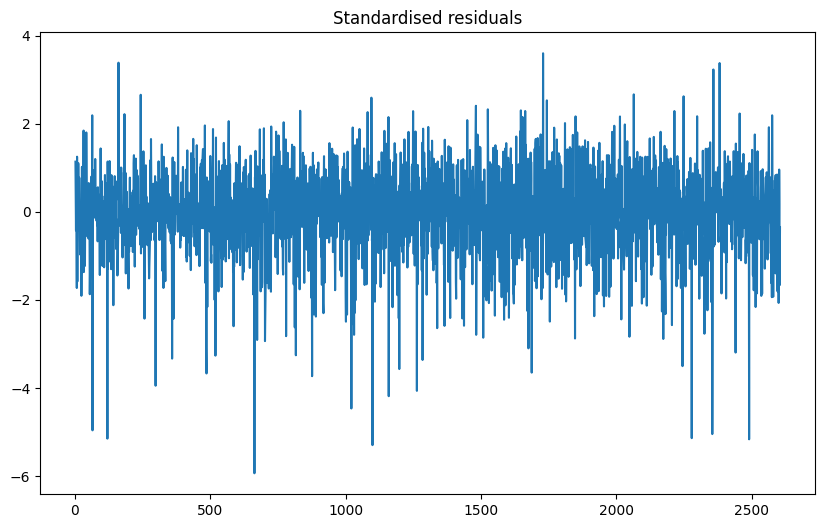


ACF for standardised residuals:



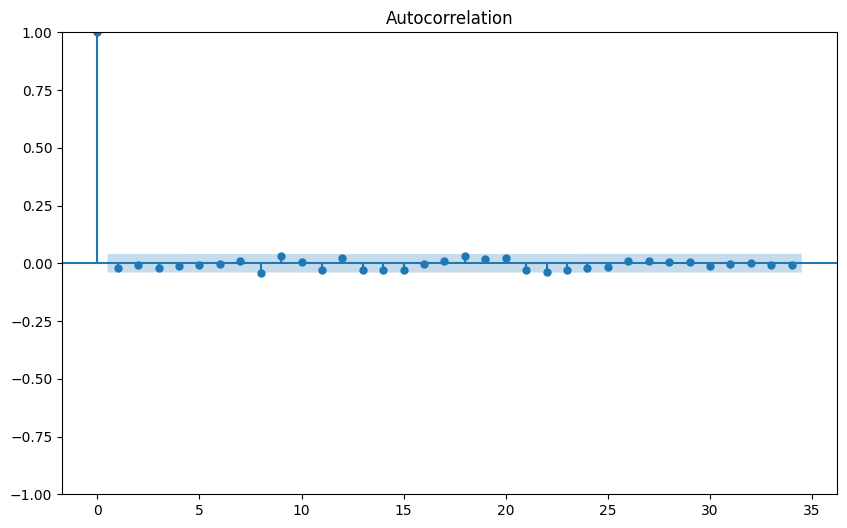

In [233]:
# Extract standardised residuals
gm_std_resid = gm_result.std_resid

# Import the Python module
from statsmodels.graphics.tsaplots import plot_acf

# Plot the standardized residuals
plt.figure(figsize = (10, 6))
plt.plot(gm_std_resid)
plt.title("Standardised residuals")
print("\nStandardised residuals:\n")
plt.show()

# Generate ACF plot of the standardized residuals
fig = plot_acf(gm_std_resid, alpha = 0.05)
fig.set_size_inches(10, 6)

print("\nACF for standardised residuals:\n")
plt.show()

### Ljung-Box

In [234]:
# Import the Python module
from statsmodels.stats.diagnostic import acorr_ljungbox

# Perform the Ljung-Box test
# H0: Independent residuals
lb_test = acorr_ljungbox(gm_std_resid , lags = 10, return_df = True)

# Print the p-values
print("\nLjung-Box test statistics and p-values:\n")
lb_test


Ljung-Box test statistics and p-values:



,lb_stat,lb_pvalue
1,1.030745,0.309984
2,1.122126,0.570602
3,2.045958,0.562923
4,2.383135,0.665677
5,2.522663,0.773078
6,2.564059,0.861231
7,2.746892,0.907388
8,7.016919,0.534808
9,9.261849,0.413463
10,9.335626,0.500575


## Forecast and backtesting

- too wide a window may result in higher variance
- too narrow a window may result in a higher bias
- optimal window size balances the trade-off between bias and variance

``` Python
# Expanding window
for i in range(120):
	gm_result = basic_gm.fit(
		first_obs = start_loc,
		last_obs = i + end_loc,
		disp = "off"
	)
	temp_result = gmresult.forecast(horizon = 1).variance

# Fixed rolling window
for i in range(120):
	gm_result = basic_gm.fit(
		first_obs = i + start_loc,
		last_obs = i + end_loc,
		disp = "off"
	)
	temp_result = gm_result.forecast(horizon = 1).variance
```

### Assess forecast

- use MSE/MAE to assess in- and out-of-sample performance.

Mean absolute error (MAE)

$$
MAE = \frac{1}{N}\sum_{i=1}^N\vert y_i-\hat{y}_i\vert
$$

Mean squared error (MSE)

$$
MSE = \frac{1}{N}\sum_{i=1}^N (y_i-\hat{y}_i)^2
$$

### Fit a model of choice

In [235]:
# Specify GARCH model assumptions
fmodel = arch_model(snp_returns, p = 1, q = 1, mean = "constant", vol = "GARCH", dist = "skewt")

# Fit the model
fmodel_result = fmodel.fit(update_freq = 4)

# Display model fitting summary
print(fmodel_result.summary())

Iteration:      4,   Func. Count:     40,   Neg. LLF: 3006.334105588149
Iteration:      8,   Func. Count:     72,   Neg. LLF: 337157.406009416
Iteration:     12,   Func. Count:    104,   Neg. LLF: 2974.823703417477
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2974.823702579876
            Iterations: 13
            Function evaluations: 111
            Gradient evaluations: 13
                           Constant Mean - GARCH Model Results                           
Dep. Variable:                        log_return   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                 GARCH   Log-Likelihood:               -2974.82
Distribution:      Standardized Skew Student's t   AIC:                           5961.65
Method:                       Maximum Likelihood   BIC:                           5996.38
                                   

### Fixed-point forecast

In [236]:
# Extract conditional volatility from the model
gm_sigma = fmodel_result.conditional_volatility
#gmf_sigma = gm_result.forecast(horizon = 5, reindex = False).variance
gmf_sigma = fmodel_result.forecast(horizon = 5, method = "simulation", simulations = 1000, reindex = False).simulations.variances[-1]
gm_dates = snp.date

min_date = np.min(df.date)
max_date = np.max(df.date)

lower = np.percentile(gmf_sigma, 5, axis = 0)**0.5
upper = np.percentile(gmf_sigma, 95, axis = 0)**0.5

In [237]:
# Construct a continuous historical-forecast df
gm_sigma_df = pd.DataFrame({
    "date": df.date,
    "type": "historical",
    "sigma": gm_sigma
}).dropna()

gmf_sigma_df = pd.DataFrame({
    "date": pd.date_range(
        start = max_date  + pd.Timedelta(days = 1),
        periods = 5,
        freq = "B"
    ),
    "type": "forecast",
    #"sigma": np.sqrt(gmf_sigma.to_numpy().flatten())
    "sigma": pd.DataFrame(np.sqrt(gmf_sigma)).median(axis = 0)
})

tsf_sigma_df = pd.concat([gm_sigma_df, gmf_sigma_df], axis = 0)

print("\ndf of historical and forecasted volatility:\n")
tsf_sigma_df.tail()


df of historical and forecasted volatility:



,date,type,sigma
0,2026-03-20,forecast,0.934967
1,2026-03-23,forecast,0.890646
2,2026-03-24,forecast,0.874952
3,2026-03-25,forecast,0.862574
4,2026-03-26,forecast,0.861169



Historical and forecasted volatility:



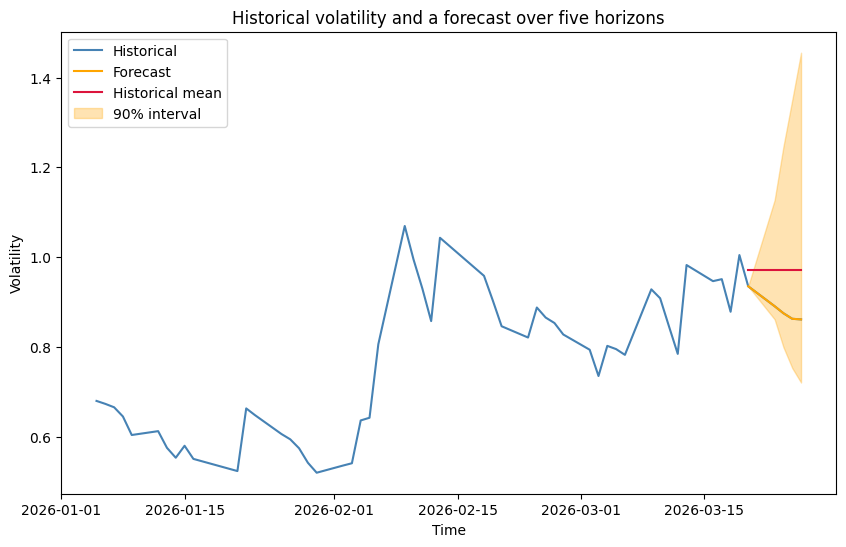

In [238]:
# Plot
plt.figure(figsize=(10, 6))

hist = tsf_sigma_df[tsf_sigma_df["type"] == "historical"]
hist = tsf_sigma_df[tsf_sigma_df["date"] >= "2026-01-01" ]
mean = tsf_sigma_df[tsf_sigma_df["type"] == "historical"]["sigma"].mean()
fore = tsf_sigma_df[tsf_sigma_df["type"] == "forecast"]
baseline = fore[["date"]].copy()
baseline["avg"] = mean

plt.plot(hist.date, hist.sigma, color = "steelblue", label = "Historical")
plt.plot(fore.date, fore.sigma, color = "orange", label = "Forecast")
plt.plot(baseline.date, baseline.avg, color = "crimson", label = "Historical mean")

plt.fill_between(fore.date, lower, upper, alpha = 0.3, color = "orange", label = "90% interval")

plt.title("Historical volatility and a forecast over five horizons")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()

print("\nHistorical and forecasted volatility:\n")
plt.show()


### Rolling forecast

#### Analytic forecast

Compute,

$$\mathbb{E}_t[\sigma_{t+1}^2]$$

Substitute the GARCH model into the expectation,

$$\sigma_{t+1}^2 = \omega + \alpha \epsilon_t^2 + \beta \sigma_t^2$$

Take expectation conditional on information at time $t$,

$$\mathbb{E}_t[\epsilon_t^2] = \sigma_t^2$$

The analytic solution follows,

$$\mathbb{E}_t[\sigma_{t+1}^2]
= \omega + \alpha \sigma_t^2 + \beta \sigma_t^2
= \omega + (\alpha + \beta)\sigma_t^2$$

In [260]:
# Fixed rolling window
rwf_df = pd.DataFrame({
    "date": df.date,
    "historical_sigma": fmodel_result.conditional_volatility
}).dropna()

forecast_steps = 120
window_size = rwf_df.shape[0] - forecast_steps
start_loc = 0
end_loc = window_size

print(f"Window size:      {end_loc - start_loc} observations")
print(f"Forecast steps:   {forecast_steps}")
print(f"Final obs fitted: {end_loc + forecast_steps - 1}")
print(f"Total data:       {len(rwf_df)}")

Window size:      2295 observations
Forecast steps:   120
Final obs fitted: 2414
Total data:       2415


In [261]:
# Roll the window
rwf_df["forecast_var"] = np.nan

for i in range(forecast_steps):
	result = fmodel.fit(
		first_obs = i + start_loc,
		last_obs = i + end_loc,
		disp = "off"
	)

	forecast = result.forecast(horizon = 1, reindex = False).variance.iloc[-1, 0]

	rwf_df.loc[rwf_df.index[end_loc + i], "forecast_var"] = forecast

rwf_df["forecast_sigma"] = np.sqrt(rwf_df["forecast_var"])

print("\nAnalytic rolling window forecast:\n")
rwf_df.tail()


Analytic rolling window forecast:



,date,historical_sigma,forecast_var,forecast_sigma
2600,2026-03-13,0.982323,0.869909,0.932689
2601,2026-03-16,0.946452,0.869225,0.932323
2602,2026-03-17,0.950874,0.869946,0.932709
2603,2026-03-18,0.878207,0.869506,0.932473
2604,2026-03-19,1.004586,0.869644,0.932547



One-step ahead analytic rolling forecast of volatility:



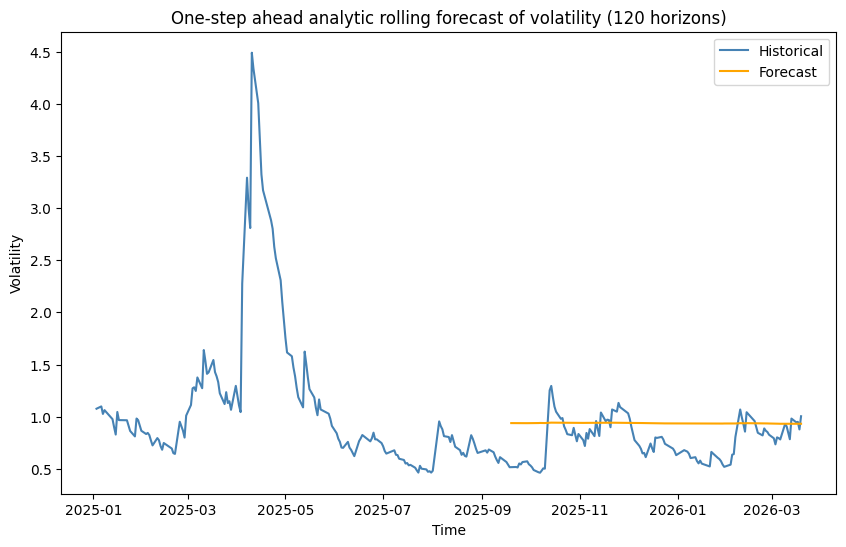

In [262]:
# Plot
plt.figure(figsize=(10, 6))

rwf_df = rwf_df[rwf_df["date"] > "2025-01-01"]
analytic_rwf = rwf_df

plt.plot(rwf_df.date, rwf_df.historical_sigma, color = "steelblue", label = "Historical")
plt.plot(rwf_df.date, rwf_df.forecast_sigma, color = "orange", label = "Forecast")

plt.title("One-step ahead analytic rolling forecast of volatility (120 horizons)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()

print("\nOne-step ahead analytic rolling forecast of volatility:\n")
plt.show()

#### Simulation forecast

Simulate the innovations,

$$z_t^{(s)} \sim \mathcal{N}(0,1)$$

Scale the innovations as per the GARCH model,

$$\epsilon_t^{(s)} = \sigma_t z_t^{(s)}$$

Propagate,

$$\sigma_{t+1}^{2,(s)} = \omega + \alpha (\epsilon_t^{(s)})^2 + \beta \sigma_t^2$$

Get a set of simulated draws,

$${\sigma_{t+1}^{2,(s)}}_{s=1}^{S}$$


In [ ]:
# Roll the window
rwf_df = pd.DataFrame({
    "date": df.date,
    "historical_sigma": fmodel_result.conditional_volatility
}).dropna()

rwf_df["forecast_var_lo"] = np.nan
rwf_df["forecast_var_hi"] = np.nan

for i in range(forecast_steps):
    result = fmodel.fit(
        first_obs = i + start_loc,
        last_obs = i + end_loc,
        disp = "off"
    )

    sim = result.forecast(
        horizon = 1,
        method = "simulation",
        simulations = 1000,
        reindex = False
    )

    sim_var = sim.simulations.variances[0, :, 0]

    # Compute the median and quantiles
    rwf_df.loc[rwf_df.index[end_loc + i], "forecast_var"] = np.median(sim_var)
    rwf_df.loc[rwf_df.index[end_loc + i], "forecast_var_lo"] = np.percentile(sim_var, 5)
    rwf_df.loc[rwf_df.index[end_loc + i], "forecast_var_hi"] = np.percentile(sim_var, 95)

rwf_df["forecast_sigma"] = np.sqrt(rwf_df["forecast_var"])
rwf_df["forecast_sigma_lo"] = np.sqrt(rwf_df["forecast_var_lo"])
rwf_df["forecast_sigma_hi"] = np.sqrt(rwf_df["forecast_var_hi"])

fore = rwf_df.dropna(subset=["forecast_sigma"])


One-step ahead simulated rolling forecast of volatility:



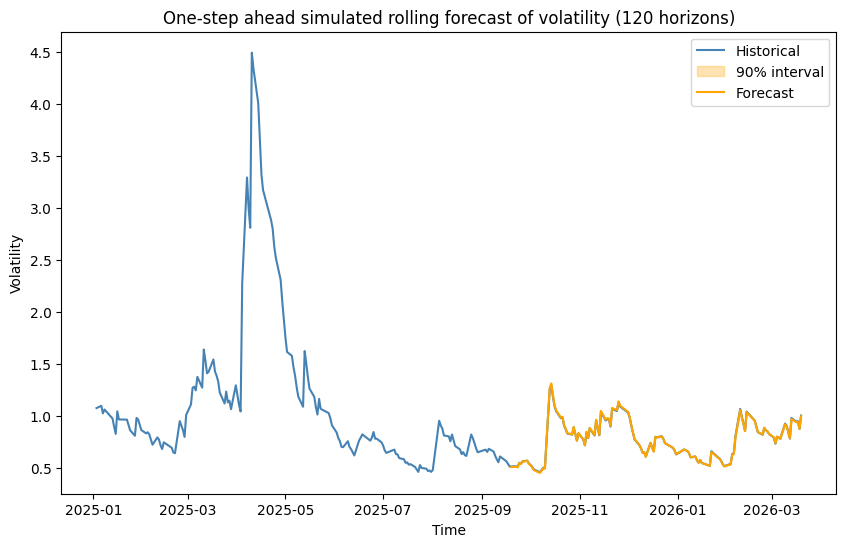

In [264]:
# Plot
plt.figure(figsize=(10, 6))

rwf_df = rwf_df[rwf_df["date"] > "2025-01-01"]
simulated_rwf = rwf_df

plt.plot(rwf_df.date, rwf_df.historical_sigma, color = "steelblue", label = "Historical")
plt.fill_between(
    fore.date, fore.forecast_sigma_lo, fore.forecast_sigma_hi,
    alpha = 0.3, color = "orange", label = "90% interval"
)
plt.plot(fore.date, fore.forecast_sigma, color="orange", label="Forecast")

plt.title("One-step ahead simulated rolling forecast of volatility (120 horizons)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()

print("\nOne-step ahead simulated rolling forecast of volatility:\n")
plt.show()


In [265]:
# Performance evaluation
rwf_df_test = rwf_df.dropna().copy()

# Backtest model with MSE/MAE
print("\nMSE/MAE for the rolling forecast:\n")
evaluate(rwf_df_test.historical_sigma, rwf_df_test.forecast_sigma)


MSE/MAE for the rolling forecast:

Mean Absolute Error (MAE): 0.00422
Mean Squared Error (MSE): 2.93e-05


(0.0042226353226417455, 2.932658267851958e-05)

In [269]:
# Compare the models
analytic_rwf = analytic_rwf.dropna()
simulated_rwf = simulated_rwf.dropna()

analytic_error = evaluate(analytic_rwf.historical_sigma, analytic_rwf.forecast_sigma)
simulated_error = evaluate(simulated_rwf.historical_sigma, simulated_rwf.forecast_sigma)

pd.DataFrame({
    "model": ["analytic", "simulated"],
    "MSE": [analytic_error[1], simulated_error[1]],
    "MAE": [analytic_error[0], simulated_error[0]]
}).T

Mean Absolute Error (MAE): 0.203
Mean Squared Error (MSE): 0.0605
Mean Absolute Error (MAE): 0.00422
Mean Squared Error (MSE): 2.93e-05


,0,1
model,analytic,simulated
MSE,0.060479,0.000029
MAE,0.202946,0.004223


As we can see in the graphs and performance metrics, the simulated model does much better. This is to be expected.

Analytic forecast replaces noise with its expectation like so, $\epsilon_{t+1}^2 \rightarrow \mathbb{E}_t[\epsilon_{t+1}^2] = \sigma_{t+1}^2$. We therefore forecast the signal driven by persistence given by the estimated parameters $\alpha$ and $\beta$.

Simulated forecast computes tomorrow's volatility from the present and random noise like so, $\epsilon_{t+1}^2 \rightarrow \epsilon_{t+1}^2 = \sigma_{t+1}^2 z_{t+1}^2, z_{t+1} \sim (0,1)$.

A one-step-ahead simulated forecast therefore seems to track the evolution of historical volatility much more closely.